In [1]:
import glob
import os
import h5py
import numpy as np
from astropy.cosmology import Planck18
import astropy.units as u
import bilby
import json
from bilby.gw.conversion import (
    symmetric_mass_ratio_to_mass_ratio,
    lambda_1_lambda_2_to_lambda_tilde,
    lambda_1_lambda_2_to_delta_lambda_tilde,
    redshift_to_luminosity_distance,
)
import collections

In [2]:
BASE_PATH   = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns'
BNS_PATH    = BASE_PATH + '/bns/networks/'
NSBH_PATH   = BASE_PATH + '/bhns/networks/'
OUTPUT_FILE = BASE_PATH + 'bns_nsbh_fisher_gaussians.h5'

PARAM_IDX = {
    'Mc':          0,
    'eta':         1,
    'dL':          2,
    'theta':       3,
    'phi':         4,
    'iota':        5,
    'psi':         6,
    'tcoal':       7,
    'Phicoal':     8,
    'chi1z':       9,
    'chi2z':       10,
    'LambdaTilde': 11,
    'deltaLambda': 12,
}

In [3]:
import sys

SAMPLER_DIR = (BASE_PATH + '/CE_STM_CBC/pop_models/stellar_mass/'
               'injection_sampler_v2')
EOS_DIR = SAMPLER_DIR + '/sfho_compose_files'

# drop any copy imported from another sampler version earlier in this kernel
sys.modules.pop('generate_tidal_params_correct', None)
sys.path.insert(0, SAMPLER_DIR)

import generate_tidal_params_correct as gtp
from generate_tidal_params_correct import LambdaCalculator, MSUN_GEOM, TOV_RTOL

assert gtp.__file__.startswith(SAMPLER_DIR), f'wrong module: {gtp.__file__}'
print(f'module: {gtp.__file__}')

# 1000 TOV solves at rtol=1e-6, takes a few minutes; build once and reuse
calc = LambdaCalculator(EOS_DIR, method='interp', mmin=1.0)
print(f'TOV max mass: {calc.eos_max_mass:.4f} Msun')
print(f'Lambda(1.4):   {calc.get_lambda(1.4):.2f}')

module: /ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/CE_STM_CBC/pop_models/stellar_mass/injection_sampler_v2/generate_tidal_params_correct.py
Loading Pressure - Energy from cache: /ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/CE_STM_CBC/pop_models/stellar_mass/injection_sampler_v2/sfho_compose_files/sfho_p_e_geom.txt
TOV max mass: 2.0600 Msun
Lambda(1.4):   336.35


In [4]:
# g/cm^3 -> geometric m^-2, same factor generate_tidal_params_correct uses
GCM3_TO_GEOM = (bilby.utils.gravitational_constant / bilby.utils.speed_of_light**2) * 1e3

def eos_curves(calc, n_grid=400):
    """Build the EOS metadata arrays from a LambdaCalculator instead of the npz."""
    fam = calc.fam

    mass = np.asarray(fam.mass) / MSUN_GEOM
    lam = np.asarray(fam.tidal_deformability)
    radius = np.asarray(fam.radius) / 1e3

    order = np.argsort(mass)
    mass, lam, radius = mass[order], lam[order], radius[order]

    good = np.isfinite(mass) & np.isfinite(lam) & (lam > 0) & (mass >= calc.mmin)
    mass, lam, radius = mass[good], lam[good], radius[good]

    # stop at the cap get_lambda enforces, else the tail comes back as zeros
    mass_top = min(mass[-1], calc.eos_max_mass)

    # dense grid through the same PCHIP interpolant used to assign Lambda1/Lambda2
    mass_grid = np.linspace(calc.mmin, mass_top, n_grid)
    lambda_grid = calc.get_lambda(mass_grid)
    radius_grid = np.interp(mass_grid, mass, radius)

    return {
        'eos_name':     'SFHo',
        'eos_dir':      EOS_DIR,
        'tov_rtol':     TOV_RTOL,
        'mmin_msol':    calc.mmin,
        'M_max_TOV':    float(calc.eos_max_mass),
        'Lambda_1p4':   float(calc.get_lambda(1.4)),
        'Lambda_max':   float(lambda_grid.max()),
        'R_1p4_km':     float(np.interp(1.4, mass, radius)),
        'mass_msol':    mass_grid,
        'lambda':       lambda_grid,
        'radius_km':    radius_grid,
        'pressure_gcc': np.asarray(fam.eos.pressure) / GCM3_TO_GEOM,
        'edensity_gcc': np.asarray(fam.eos.energy_density) / GCM3_TO_GEOM,
    }

def write_eos_metadata(out, calc):
    """Write the eos_metadata group, replacing the old npz block."""
    eos = eos_curves(calc)
    grp = out.create_group('eos_metadata')

    for key in ['eos_name', 'eos_dir', 'tov_rtol', 'mmin_msol',
                'M_max_TOV', 'Lambda_1p4', 'Lambda_max', 'R_1p4_km']:
        grp.attrs[key] = eos[key]

    for key in ['mass_msol', 'lambda', 'radius_km', 'pressure_gcc', 'edensity_gcc']:
        grp.create_dataset(key, data=eos[key])

    return grp

In [5]:
INVERSION_ERROR_MAX = 0.1

# files sit in networks{7,8,9,14,56} subdirs, so the glob has to recurse
BNS_FILES = sorted(glob.glob(BASE_PATH + '/bns/networks/**/*.h5', recursive=True))

# shortens the 60-character network names so the table fits the text width
NAME_SUBS = [('CE40km', 'CE40'), ('CE20km', 'CE20'), ('1p0MW', '1.0'), ('1p5MW', '1.5'),
             ('Aplus_coat', 'A+'), ('aLIGO_coat', 'aL'), ('Asharp', r'A\#'),
             ('.0hz', ''), ('hz', '')]


def check_file(src_file, error_max=INVERSION_ERROR_MAX):
    """Count events dropped by the cut. error_max=None drops only the NaN inversion errors."""
    with h5py.File(src_file, 'r') as f:
        det = np.where(f['is_detected'][:].astype(bool))[0]
        param_idx = json.loads(f.attrs['parameters_indices'])
        inv_err = f['inversion_errors'][:][det]
        var = {name: f['covariance'][i, i, :][det] for name, i in param_idx.items()}
        ev = {k: f['event_parameters'][k][:][det] for k in f['event_parameters']}

    nan_err = ~np.isfinite(inv_err)
    if error_max is None:
        over = np.zeros_like(nan_err)
        keep = ~nan_err
    else:
        over = ~nan_err & (inv_err >= error_max)
        keep = ~nan_err & (inv_err < error_max)

    sigma = {name: np.sqrt(np.abs(v)) for name, v in var.items()}
    root = np.sqrt(np.clip(1.0 - 4.0 * ev['eta'], 0.0, None))
    dq_deta = np.where(root > 0, 4.0 / (root * (1.0 + root) ** 2), np.inf)

    converted = {
        'Mc_src':       ev['Mc'] / (1.0 + ev['z']),
        'sigma_Mc_src': sigma['Mc'] / (1.0 + ev['z']),
        'q':            bilby.gw.conversion.symmetric_mass_ratio_to_mass_ratio(ev['eta']),
        'sigma_q':      dq_deta * sigma['eta'],
        'LambdaTilde':  bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(
                            ev['Lambda1'], ev['Lambda2'], ev['m1_src'], ev['m2_src']),
        'deltaLambda':  bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(
                            ev['Lambda1'], ev['Lambda2'], ev['m1_src'], ev['m2_src']),
    }

    passes = True
    for v in var.values():
        if np.any(~np.isfinite(v[keep])) or np.any(v[keep] < 0):
            passes = False
    for v in list(ev.values()) + list(converted.values()):
        if np.any(~np.isfinite(v[keep])):
            passes = False

    return {
        'n_detected': det.size,
        'n_nan_err': int(nan_err.sum()),
        'n_over': int(over.sum()),
        'n_keep': int(keep.sum()),
        'passes': passes,
    }


def latex_name(src_file):
    """Abbreviated network name; underscores become spaces so nothing needs escaping."""
    name = os.path.basename(src_file).replace('network_bns_', '').replace('.h5', '')
    for old, new in NAME_SUBS:
        name = name.replace(old, new)
    return name.replace('_', ' ')


HEADER = (r'Network & Detected & NaN error & $\geq ' + f'{INVERSION_ERROR_MAX}'
          + r'$ & Dropped & Kept \\')

# longtable breaks across pages; it cannot sit inside \resizebox, so \small does the fitting
print(r'\begin{center}')
print(r'\small')
print(r'\begin{longtable}{lrrrrr}')
print(r'\caption{BNS networks before and after the Fisher inversion error cut.}')
print(r'\label{tab:bns_inversion_cut} \\')
print(r'\hline')
print(HEADER)
print(r'\hline')
print(r'\endfirsthead')
print(r'\caption[]{\textit{continued from previous page}} \\')
print(r'\hline')
print(HEADER)
print(r'\hline')
print(r'\endhead')
print(r'\hline')
print(r'\multicolumn{6}{r}{\textit{continued on next page}} \\')
print(r'\endfoot')
print(r'\hline')
print(r'\endlastfoot')

tot = collections.Counter()
failed = []
for fpath in BNS_FILES:
    r = check_file(fpath)
    dropped = r['n_nan_err'] + r['n_over']
    tot['detected'] += r['n_detected']
    tot['nan_err']  += r['n_nan_err']
    tot['over']     += r['n_over']
    tot['keep']     += r['n_keep']
    if not r['passes']:
        failed.append(fpath)

    print(f'{latex_name(fpath)} & {r["n_detected"]} & {r["n_nan_err"]} & '
          f'{r["n_over"]} & {dropped} & {r["n_keep"]} \\\\')

print(r'\hline')
print(f'Total & {tot["detected"]} & {tot["nan_err"]} & {tot["over"]} & '
      f'{tot["nan_err"] + tot["over"]} & {tot["keep"]} \\\\')
print(r'\end{longtable}')
print(r'\end{center}')

if failed:
    print(f'\n{len(failed)} of {len(BNS_FILES)} files DO NOT pass after the cut')
else:
    print(f'\nAll {len(BNS_FILES)} files pass after the cut')

\begin{center}
\small
\begin{longtable}{lrrrrr}
\caption{BNS networks before and after the Fisher inversion error cut.}
\label{tab:bns_inversion_cut} \\
\hline
Network & Detected & NaN error & $\geq 0.1$ & Dropped & Kept \\
\hline
\endfirsthead
\caption[]{\textit{continued from previous page}} \\
\hline
Network & Detected & NaN error & $\geq 0.1$ & Dropped & Kept \\
\hline
\endhead
\hline
\multicolumn{6}{r}{\textit{continued on next page}} \\
\endfoot
\hline
\endlastfoot
CE40 1.0 A+ 10 CE20 1.0 A+ 10 LIA+ 10 & 29253 & 530 & 83 & 613 & 28640 \\
CE40 1.0 A+ 15 CE20 1.0 A+ 15 LIA+ 10 & 23804 & 211 & 38 & 249 & 23555 \\
CE40 1.0 A+ 5 CE20 1.0 A+ 5 LIA+ 10 & 30932 & 317 & 70 & 387 & 30545 \\
CE40 1.0 A+ 7 CE20 1.0 A+ 7 LIA+ 10 & 30719 & 329 & 54 & 383 & 30336 \\
CE40 1.0 aL 10 CE20 1.0 aL 10 LIA+ 10 & 19858 & 364 & 52 & 416 & 19442 \\
CE40 1.0 aL 15 CE20 1.0 aL 15 LIA+ 10 & 15340 & 131 & 27 & 158 & 15182 \\
CE40 1.0 aL 5 CE20 1.0 aL 5 LIA+ 10 & 21593 & 236 & 43 & 279 & 21314 \\
CE40 1.0 aL 

In [6]:
NSBH_FILES = sorted(glob.glob(BASE_PATH + '/bhns/networks/**/*.h5', recursive=True))


def latex_name_nsbh(src_file):
    """Same abbreviation as the BNS table, for the nsbh filename prefix."""
    name = os.path.basename(src_file).replace('network_nsbh_', '').replace('.h5', '')
    for old, new in NAME_SUBS:
        name = name.replace(old, new)
    return name.replace('_', ' ')


def why_failed(src_file, error_max=INVERSION_ERROR_MAX):
    """List every quantity still NaN or negative among the events the cut keeps."""
    with h5py.File(src_file, 'r') as f:
        det = np.where(f['is_detected'][:].astype(bool))[0]
        param_idx = json.loads(f.attrs['parameters_indices'])
        inv_err = f['inversion_errors'][:][det]
        var = {name: f['covariance'][i, i, :][det] for name, i in param_idx.items()}
        ev = {k: f['event_parameters'][k][:][det] for k in f['event_parameters']}

    nan_err = ~np.isfinite(inv_err)
    keep = ~nan_err if error_max is None else (~nan_err & (inv_err < error_max))

    sigma = {name: np.sqrt(np.abs(v)) for name, v in var.items()}
    root = np.sqrt(np.clip(1.0 - 4.0 * ev['eta'], 0.0, None))
    dq_deta = np.where(root > 0, 4.0 / (root * (1.0 + root) ** 2), np.inf)

    converted = {
        'Mc_src':       ev['Mc'] / (1.0 + ev['z']),
        'sigma_Mc_src': sigma['Mc'] / (1.0 + ev['z']),
        'q':            bilby.gw.conversion.symmetric_mass_ratio_to_mass_ratio(ev['eta']),
        'sigma_q':      dq_deta * sigma['eta'],
        'LambdaTilde':  bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(
                            ev['Lambda1'], ev['Lambda2'], ev['m1_src'], ev['m2_src']),
        'deltaLambda':  bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(
                            ev['Lambda1'], ev['Lambda2'], ev['m1_src'], ev['m2_src']),
    }

    n = int(keep.sum())
    problems = []
    if n == 0:
        return problems
    for name, v in var.items():
        vk = v[keep]
        n_nan, n_neg = int(np.sum(~np.isfinite(vk))), int(np.sum(vk < 0))
        if n_nan:
            problems.append((f'var({name})', 'NaN', n_nan, n))
        if n_neg:
            problems.append((f'var({name})', 'negative', n_neg, n))
    for label, table in [('injected', ev), ('converted', converted)]:
        for name, v in table.items():
            n_nan = int(np.sum(~np.isfinite(v[keep])))
            if n_nan:
                problems.append((f'{label} {name}', 'NaN', n_nan, n))
    return problems


print(r'\begin{center}')
print(r'\small')
print(r'\begin{longtable}{lrrrrr}')
print(r'\caption{NSBH networks before and after the Fisher inversion error cut.}')
print(r'\label{tab:nsbh_inversion_cut} \\')
print(r'\hline')
print(HEADER)
print(r'\hline')
print(r'\endfirsthead')
print(r'\caption[]{\textit{continued from previous page}} \\')
print(r'\hline')
print(HEADER)
print(r'\hline')
print(r'\endhead')
print(r'\hline')
print(r'\multicolumn{6}{r}{\textit{continued on next page}} \\')
print(r'\endfoot')
print(r'\hline')
print(r'\endlastfoot')

tot_nsbh = collections.Counter()
failed_nsbh = []
for fpath in NSBH_FILES:
    r = check_file(fpath)
    dropped = r['n_nan_err'] + r['n_over']
    tot_nsbh['detected'] += r['n_detected']
    tot_nsbh['nan_err']  += r['n_nan_err']
    tot_nsbh['over']     += r['n_over']
    tot_nsbh['keep']     += r['n_keep']
    if not r['passes']:
        failed_nsbh.append(fpath)

    print(f'{latex_name_nsbh(fpath)} & {r["n_detected"]} & {r["n_nan_err"]} & '
          f'{r["n_over"]} & {dropped} & {r["n_keep"]} \\\\')

print(r'\hline')
print(f'Total & {tot_nsbh["detected"]} & {tot_nsbh["nan_err"]} & {tot_nsbh["over"]} & '
      f'{tot_nsbh["nan_err"] + tot_nsbh["over"]} & {tot_nsbh["keep"]} \\\\')
print(r'\end{longtable}')
print(r'\end{center}')

if failed_nsbh:
    print(f'\n{len(failed_nsbh)} of {len(NSBH_FILES)} files DO NOT pass after the cut')

    tally = collections.Counter()
    worst = {}
    for fpath in failed_nsbh:
        for what, kind, count, n_kept in why_failed(fpath):
            tally[(what, kind)] += 1
            worst[(what, kind)] = max(worst.get((what, kind), 0.0), 100 * count / n_kept)

    print(f'\n{"quantity":24s}{"problem":10s}{"files":>7s}{"worst % of kept":>18s}')
    for (what, kind), n_files in sorted(tally.items(), key=lambda kv: -kv[1]):
        print(f'{what:24s}{kind:10s}{n_files:7d}{worst[(what, kind)]:17.2f}%')
else:
    print(f'\nAll {len(NSBH_FILES)} files pass after the cut')


\begin{center}
\small
\begin{longtable}{lrrrrr}
\caption{NSBH networks before and after the Fisher inversion error cut.}
\label{tab:nsbh_inversion_cut} \\
\hline
Network & Detected & NaN error & $\geq 0.1$ & Dropped & Kept \\
\hline
\endfirsthead
\caption[]{\textit{continued from previous page}} \\
\hline
Network & Detected & NaN error & $\geq 0.1$ & Dropped & Kept \\
\hline
\endhead
\hline
\multicolumn{6}{r}{\textit{continued on next page}} \\
\endfoot
\hline
\endlastfoot
CE40 1.0 A+ 10 CE20 1.0 A+ 10 LIA+ 10 & 22423 & 0 & 98 & 98 & 22325 \\
CE40 1.0 A+ 15 CE20 1.0 A+ 15 LIA+ 10 & 19554 & 0 & 73 & 73 & 19481 \\
CE40 1.0 A+ 5 CE20 1.0 A+ 5 LIA+ 10 & 23189 & 0 & 137 & 137 & 23052 \\
CE40 1.0 A+ 7 CE20 1.0 A+ 7 LIA+ 10 & 23081 & 0 & 107 & 107 & 22974 \\
CE40 1.0 aL 10 CE20 1.0 aL 10 LIA+ 10 & 17533 & 0 & 79 & 79 & 17454 \\
CE40 1.0 aL 15 CE20 1.0 aL 15 LIA+ 10 & 14744 & 0 & 58 & 58 & 14686 \\
CE40 1.0 aL 5 CE20 1.0 aL 5 LIA+ 10 & 18525 & 0 & 113 & 113 & 18412 \\
CE40 1.0 aL 7 CE20 1.0 aL

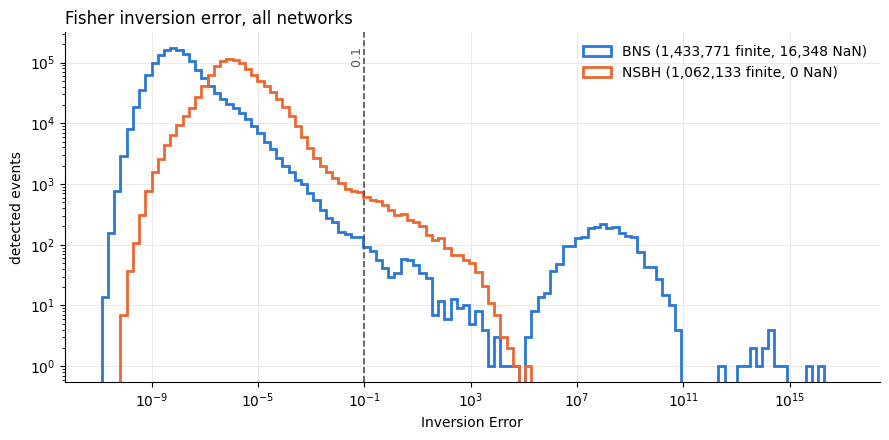

BNS   min 1.33e-11  p1 2.18e-10  median 9.31e-09  p99 4.59e-05  max 1.01e+17   below 0.1: 99.80%
NSBH  min 8.33e-11  p1 5.46e-09  median 1.3e-06  p99 0.00384  max 1.16e+05   below 0.1: 99.57%


In [7]:
import matplotlib.pyplot as plt


def gather_inversion_errors(files):
    """Inversion errors of all detected events, and how many are NaN."""
    vals, n_nan = [], 0
    for fpath in files:
        with h5py.File(fpath, 'r') as f:
            det = np.where(f['is_detected'][:].astype(bool))[0]
            ie = f['inversion_errors'][:][det]
        n_nan += int(np.sum(~np.isfinite(ie)))
        vals.append(ie[np.isfinite(ie) & (ie > 0)])
    return np.concatenate(vals), n_nan


bns_ie, bns_nan = gather_inversion_errors(BNS_FILES)
nsbh_ie, nsbh_nan = gather_inversion_errors(NSBH_FILES)

bins = np.logspace(np.log10(min(bns_ie.min(), nsbh_ie.min())),
                   np.log10(max(bns_ie.max(), nsbh_ie.max())), 120)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(bns_ie, bins=bins, histtype='step', lw=2, color='#2a78d6',
        label=f'BNS ({bns_ie.size:,} finite, {bns_nan:,} NaN)')
ax.hist(nsbh_ie, bins=bins, histtype='step', lw=2, color='#eb6834',
        label=f'NSBH ({nsbh_ie.size:,} finite, {nsbh_nan:,} NaN)')

ax.axvline(0.1, color='#52514e', lw=1.2, ls='--')
ax.text(0.1, 0.97, ' 0.1 ', transform=ax.get_xaxis_transform(),
        rotation=90, va='top', ha='right', color='#52514e', fontsize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Inversion Error')
ax.set_ylabel('detected events')
ax.set_title('Fisher inversion error, all networks', loc='left')
ax.legend(frameon=False)
ax.grid(True, color='#e8e7e0', lw=0.6)
ax.set_axisbelow(True)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

for label, arr in [('BNS', bns_ie), ('NSBH', nsbh_ie)]:
    p1, p50, p99 = np.percentile(arr, [1, 50, 99])
    print(f'{label:5s} min {arr.min():.3g}  p1 {p1:.3g}  median {p50:.3g}  '
          f'p99 {p99:.3g}  max {arr.max():.3g}   below 0.1: {100 * np.mean(arr < 0.1):.2f}%')

In [8]:
def process_network_file(src_file, parent_group, error_max=INVERSION_ERROR_MAX):
    with h5py.File(src_file, 'r') as f:
        detected_mask = f['is_detected'][:]
        snr_all       = f['snr'][:]
        cov_all       = f['covariance'][:]
        sky_all       = f['sky_area_90'][:]
        inv_err_all   = f['inversion_errors'][:]
        cond_all      = f['condition_numbers'][:]

        events_all = {}
        for key in f['event_parameters'].keys():
            events_all[key] = f['event_parameters'][key][:]

        detectors     = f.attrs['detectors']
        snr_threshold = float(f.attrs['snr_threshold'])
        n_total       = int(f.attrs['total_events'])
        n_detected    = int(f.attrs['detected_events'])
        param_idx     = json.loads(f.attrs['parameters_indices'])

    det = np.where(detected_mask.astype(bool))[0]
    assert len(det) == n_detected, f'Mask mismatch: {len(det)} vs {n_detected}'

    # keep only events whose Fisher inverse is trustworthy; NaN fails both tests
    inv_err = inv_err_all[det]
    if error_max is None:
        keep = np.isfinite(inv_err)
    else:
        keep = np.isfinite(inv_err) & (inv_err < error_max)

    det = det[keep]
    n_kept = len(det)

    net_name = os.path.basename(src_file).replace('network_bns_', '').replace('network_nsbh_', '').replace('.h5', '')
    if net_name in parent_group:
        print(f'  [skip] {net_name} already exists')
        return

    net_grp = parent_group.create_group(net_name)
    net_grp.attrs['detectors']            = detectors
    net_grp.attrs['snr_threshold']        = snr_threshold
    net_grp.attrs['total_events']         = n_total
    net_grp.attrs['detected_events']      = n_detected
    net_grp.attrs['kept_events']          = n_kept
    net_grp.attrs['inversion_error_max']  = np.nan if error_max is None else error_max
    net_grp.attrs['detection_efficiency'] = n_detected / n_total
    net_grp.attrs['source_file']          = os.path.basename(src_file)
    net_grp.attrs['dL_units']             = 'Gpc'

    diag      = np.array([np.diag(cov_all[:, :, i]) for i in det])
    sigma_Mc  = np.sqrt(np.abs(diag[:, param_idx['Mc']]))
    sigma_eta = np.sqrt(np.abs(diag[:, param_idx['eta']]))
    sigma_dL  = np.sqrt(np.abs(diag[:, param_idx['dL']]))
    sigma_psi = np.sqrt(np.abs(diag[:, param_idx['psi']]))
    sigma_LT  = np.sqrt(np.abs(diag[:, param_idx['LambdaTilde']]))

    has_delta = 'deltaLambda' in param_idx
    if has_delta:
        sigma_dLT = np.sqrt(np.abs(diag[:, param_idx['deltaLambda']]))

    Mc_det = events_all['Mc'][det]
    eta    = events_all['eta'][det]
    z      = events_all['z'][det]
    dL     = events_all['dL'][det]
    psi    = events_all['psi'][det]
    m1     = events_all['m1_src'][det]
    m2     = events_all['m2_src'][det]
    L1     = events_all['Lambda1'][det]
    L2     = events_all['Lambda2'][det]

    Mc_src       = Mc_det / (1.0 + z)
    sigma_Mc_src = sigma_Mc / (1.0 + z)

    q = bilby.gw.conversion.symmetric_mass_ratio_to_mass_ratio(eta)

    # analytic dq/deta; a finite difference steps past eta=0.25 and returns nan
    root    = np.sqrt(np.clip(1.0 - 4.0 * eta, 0.0, None))
    dq_deta = np.where(root > 0, 4.0 / (root * (1.0 + root) ** 2), np.inf)
    sigma_q = dq_deta * sigma_eta

    n_wide = int(np.sum(sigma_q > 1.0))
    if n_wide:
        print(f'  [note] {n_wide} events near eta=0.25 have sigma_q > 1 (linear propagation breaks down)')

    L1_conv = L1 if has_delta else np.zeros_like(L1)
    LT_inj  = bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(L1_conv, L2, m1, m2)
    dLT_inj = bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(L1_conv, L2, m1, m2)

    net_grp.create_dataset('original_indices', data=det)
    net_grp.create_dataset('snr',              data=snr_all[det])
    net_grp.create_dataset('sky_area_90',      data=sky_all[det])
    net_grp.create_dataset('inversion_error',  data=inv_err_all[det])
    net_grp.create_dataset('condition_number', data=cond_all[det])
    net_grp.create_dataset('m1_src',           data=m1)
    net_grp.create_dataset('m2_src',           data=m2)
    net_grp.create_dataset('Lambda1',          data=L1)
    net_grp.create_dataset('Lambda2',          data=L2)
    net_grp.create_dataset('z',                data=z)

    for name, mu, sig in [
        ('Mc_src',      Mc_src,   sigma_Mc_src),
        ('eta',         eta,      sigma_eta),
        ('q',           q,        sigma_q),
        ('dL',          dL,       sigma_dL),
        ('LambdaTilde', LT_inj,   sigma_LT),
        ('deltaLambda', dLT_inj,  sigma_dLT if has_delta else np.zeros_like(dLT_inj)),
        ('psi',         psi,      sigma_psi),
    ]:
        net_grp.create_dataset(f'mu_{name}',    data=mu)
        net_grp.create_dataset(f'sigma_{name}', data=sig)

    print(f'  wrote {n_kept} of {n_detected} detected events -> {net_name}')

In [9]:
# dry run on one file first
test_file = BNS_PATH + 'networks7/network_bns_CE40km_1p5MW_Aplus_coat_5.0hz_CE20km_1p5MW_Aplus_coat_5.0hz_ETD_5.0hz.h5'

with h5py.File('test_restructure.h5', 'w') as out:
    write_eos_metadata(out, calc)

    test_grp = out.create_group('BNS')
    process_network_file(test_file, test_grp)

with h5py.File('test_restructure.h5', 'r') as f:
    print('Top level keys:', list(f.keys()))
    print('EOS attrs:', dict(f['eos_metadata'].attrs))
    print()
    net = list(f['BNS'].keys())[0]
    grp = f['BNS'][net]
    print(f'Network:        {net}')
    print(f'detected_events:{grp.attrs["detected_events"]}')
    print(f'kept_events:    {grp.attrs["kept_events"]}  '
          f'(inversion_error < {grp.attrs["inversion_error_max"]})')
    print(f'dataset length: {len(grp["z"])}   matches kept? '
          f'{len(grp["z"]) == grp.attrs["kept_events"]}')
    print()
    print(f'original_indices[:3]: {grp["original_indices"][:3]}')
    print(f'snr[:3]:         {grp["snr"][:3]}')
    print(f'sky_area_90[:3]: {grp["sky_area_90"][:3]}')
    print(f'inversion_error: max {grp["inversion_error"][:].max():.3g}')
    print(f'condition_number: median {np.median(grp["condition_number"][:]):.3g}')
    print(f'm1_src[:3]:      {grp["m1_src"][:3]}')
    print(f'm2_src[:3]:      {grp["m2_src"][:3]}')
    print(f'Lambda1[:3]:     {grp["Lambda1"][:3]}')
    print(f'Lambda2[:3]:     {grp["Lambda2"][:3]}')
    print(f'z[:3]:           {grp["z"][:3]}')
    print()
    for p in ['Mc_src', 'eta', 'q', 'dL', 'LambdaTilde', 'deltaLambda', 'psi']:
        mu, sig = grp[f'mu_{p}'][:], grp[f'sigma_{p}'][:]
        n_bad = int(np.sum(~np.isfinite(mu)) + np.sum(~np.isfinite(sig)))
        print(f'{p:12s}: mu={mu[0]:12.6f}  sigma={sig[0]:12.6f}   non-finite {n_bad}')


  [note] 5051 events near eta=0.25 have sigma_q > 1 (linear propagation breaks down)
  wrote 46574 of 47641 detected events -> CE40km_1p5MW_Aplus_coat_5.0hz_CE20km_1p5MW_Aplus_coat_5.0hz_ETD_5.0hz
Top level keys: ['BNS', 'eos_metadata']
EOS attrs: {'Lambda_1p4': np.float64(336.35106975335395), 'Lambda_max': np.float64(2420.219970596007), 'M_max_TOV': np.float64(2.06), 'R_1p4_km': np.float64(11.905858616481853), 'eos_dir': '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/CE_STM_CBC/pop_models/stellar_mass/injection_sampler_v2/sfho_compose_files', 'eos_name': 'SFHo', 'mmin_msol': np.float64(1.0), 'tov_rtol': np.float64(1e-06)}

Network:        CE40km_1p5MW_Aplus_coat_5.0hz_CE20km_1p5MW_Aplus_coat_5.0hz_ETD_5.0hz
detected_events:47641
kept_events:    46574  (inversion_error < 0.1)
dataset length: 46574   matches kept? True

original_indices[:3]: [2 3 8]
snr[:3]:         [21.04737728 19.56496722 21.32450589]
sky_area_90[:3]: [42.22541588 41.30979557  5.70843324]
invers

In [10]:
# run everything once dry run looks good
OUTPUT_FILE = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/restructured_networks.h5'
bns_files  = sorted(glob.glob(BNS_PATH  + '**/*.h5', recursive=True))
nsbh_files = sorted(glob.glob(NSBH_PATH + '**/*.h5', recursive=True))

print(f'BNS files:  {len(bns_files)}')
print(f'NSBH files: {len(nsbh_files)}')

with h5py.File(OUTPUT_FILE, 'w') as out:
    write_eos_metadata(out, calc)

    bns_grp  = out.create_group('BNS')
    nsbh_grp = out.create_group('NSBH')

    for fpath in bns_files:
        print(os.path.basename(fpath))
        try:
            process_network_file(fpath, bns_grp)
        except Exception as e:
            print(f'  [ERROR] {e}')

    for fpath in nsbh_files:
        print(os.path.basename(fpath))
        try:
            process_network_file(fpath, nsbh_grp)
        except Exception as e:
            print(f'  [ERROR] {e}')

print(f'Done. Output: {OUTPUT_FILE}')

BNS files:  46
NSBH files: 46
network_bns_CE40km_1p0MW_Aplus_coat_10.0hz_CE20km_1p0MW_Aplus_coat_10.0hz_LIA+_10.0hz.h5
  [note] 6706 events near eta=0.25 have sigma_q > 1 (linear propagation breaks down)
  wrote 28640 of 29253 detected events -> CE40km_1p0MW_Aplus_coat_10.0hz_CE20km_1p0MW_Aplus_coat_10.0hz_LIA+_10.0hz
network_bns_CE40km_1p0MW_Aplus_coat_15.0hz_CE20km_1p0MW_Aplus_coat_15.0hz_LIA+_10.0hz.h5
  [note] 5627 events near eta=0.25 have sigma_q > 1 (linear propagation breaks down)
  wrote 23555 of 23804 detected events -> CE40km_1p0MW_Aplus_coat_15.0hz_CE20km_1p0MW_Aplus_coat_15.0hz_LIA+_10.0hz
network_bns_CE40km_1p0MW_Aplus_coat_5.0hz_CE20km_1p0MW_Aplus_coat_5.0hz_LIA+_10.0hz.h5
  [note] 6662 events near eta=0.25 have sigma_q > 1 (linear propagation breaks down)
  wrote 30545 of 30932 detected events -> CE40km_1p0MW_Aplus_coat_5.0hz_CE20km_1p0MW_Aplus_coat_5.0hz_LIA+_10.0hz
network_bns_CE40km_1p0MW_Aplus_coat_7.0hz_CE20km_1p0MW_Aplus_coat_7.0hz_LIA+_10.0hz.h5
  [note] 6975 eve

In [11]:
with h5py.File(OUTPUT_FILE, 'r') as f:
    min_z = float('inf')
    min_source = None
    
    for system_type in ['BNS']:#, 'NSBH']:
        for net_name in f[system_type].keys():
            z_vals = f[system_type][net_name]['z'][:]
            net_min = np.min(z_vals)
            if net_min < min_z:
                min_z = net_min
                min_source = f'{system_type}/{net_name}'
    
    print(f'Lowest z: {min_z:.6f} (from {min_source})')

Lowest z: 0.042576 (from BNS/CE40km_1p0MW_Aplus_coat_10.0hz_CE20km_1p0MW_Aplus_coat_10.0hz_LIA+_10.0hz)


In [12]:
OUTPUT_FILE = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/restructured_networks.h5'

with h5py.File(OUTPUT_FILE, 'r') as f:
    all_z = []
    for system_type in ['BNS']:#, 'NSBH']:
        for net_name in f[system_type].keys():
            all_z.extend(f[system_type][net_name]['z'][:])
    
    print(f'Lowest z: {np.min(all_z):.6f}')

Lowest z: 0.042576


In [13]:
from bilby.gw.conversion import redshift_to_luminosity_distance
import astropy.units as u

z = 0.042576
dL = redshift_to_luminosity_distance(z)  # returns value in Mpc by default
print(f'z = {z} → dL = {dL:.2f} Mpc')

z = 0.042576 → dL = 194.49 Mpc
